# Analysis of World Bank - Bangladesh Informal Firms Survey
**Author:** Milan Patel (Converted to Python)

**Date:** July 12, 2015 (Original), 2025 (Python Conversion)

## Overview

Source of data: [World Bank - Bangladesh Informal Firms Surveys 2010](http://microdata.worldbank.org/index.php/catalog/2244/related_materials)

The World Bank conducted a survey of informal firms in Bangladesh in 2010. An informal firm is a business not registered with the authorities, as opposed to a formal business which is registered with the government, and therefore is subject to a larger degree of legal scrutiny and regulation. Informal businesses often predominate the economy in developing countries, and often are informal due to the high cost of obtaining any sort of formal recognition from the government in terms of time and money, particularly relative to the low or nonexistent benefit of being registered; business registration might end up being even more costly than remaining informal due to the requirement of having to then pay taxes.

The survey asked informal business owners a series of questions covering topics ranging from business characteristics to market conditions. Surveys were conducted in a select number of districts around Bangladesh. Each record of the data indicates one business for which a survey is conducted, and includes district-level geography information (the second level administrative boundary after divisions). Geographic boundary data for Bangladesh sourced via humanitarianresponse.info from World Food Programme.

My analysis intends to explore various characteristics of firms in Bangladesh; specifically, I analyze how annual revenue relates to other variable, such as number of employees, industry sector, financing sources, and geography.

The data set contains a long list of variables from which to compare, and part of the challenge of this project is to select which variables are the most useful to bring out the story of the data. In the visualizations below, the primary dependent variable that I use is Annual Revenue for the year 2009, denominated in Bangladesh Takas, which is the local currency; in 2009, the [exchange rate](http://www.exchange-rates.org/Rate/USD/BDT/12-23-2009) was about 68.4126 takas to the US dollar. The variable is referenced in the exploratory visualizations as "q4_7", which is the variable name. Another often used variable is the number of employees of the firm, which in the exploratory visualizations is referred to as "q1_12a5a".

I should also note that I augmented the data significantly, by linking the survey data (which includes a variable for ISIC code--ISIC being an industry classification system) with ISIC section category descriptions to allow for grouping of responses by industry sector.

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
import warnings
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style and options
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 8)

# Format numbers with commas
def format_thousands(x, pos):
    return f'{x:,.0f}'

formatter = FuncFormatter(format_thousands)

In [7]:
# Load survey data
surveydata = pd.read_csv('informality_data_NEW.csv')

print(f"Survey data shape: {surveydata.shape}")
print(f"\nFirst few columns: {list(surveydata.columns[:10])}")
print(f"\nBasic info about key variables:")
print(f"Revenue (q4_7) - Non-null count: {surveydata['q4_7'].notna().sum()}")
print(f"Employees (q1_12a5a) - Non-null count: {surveydata['q1_12a5a'].notna().sum()}")
print(f"District info: {surveydata['dist'].nunique()} unique districts")

Survey data shape: (1724, 331)

First few columns: ['slno', 'or', 'nob', 'gnd', 'dist', 'q1_1', 's1_1_others', 'q1_2', 'q1_3a', 'q1_3b']

Basic info about key variables:
Revenue (q4_7) - Non-null count: 1724
Employees (q1_12a5a) - Non-null count: 1724
District info: 19 unique districts


# Analysis

## A Geographic Overview of Bangladesh

In [9]:
# Load geographic shapefile data
districtmap = gpd.read_file('shp/bgd_polbnda_adm2_wfp.shp')

# Prepare map data - convert district names to uppercase for matching
districtmap['ADM2_NAME_UPPER'] = districtmap['ADM2_NAME'].str.upper()

# Calculate averages by district
aggdata = surveydata.groupby('dist').agg({
    'q4_7': 'mean',  # average revenue
    'q1_12a5a': 'mean',  # average employees
    'slno': 'count'  # count of firms
}).reset_index()

aggdata.columns = ['dist', 'avg_revenue', 'avg_employees', 'firm_count']
aggdata['dist_upper'] = aggdata['dist'].str.upper()

print(f"Districts in survey data: {aggdata['dist'].unique()}")
print(f"Districts in map data: {districtmap['ADM2_NAME'].head(10).values}")

# Merge map and survey data
plot_data = districtmap.merge(aggdata, left_on='ADM2_NAME_UPPER', right_on='dist_upper', how='left')

print(f"Successfully merged districts: {plot_data['avg_revenue'].notna().sum()}")

Districts in survey data: ['BARISAL' 'BOGRA' 'CHITTAGONG' 'COMILLA' "COX'S BAZAR" 'DHAKA' 'DINAJPUR'
 'FARIDPUR' 'JESSORE' 'KHULNA' 'KUSHTIA' 'MYMENSINGH' 'NOAKHALI' 'PABNA'
 'PATUAKHALI' 'RAJSHAHI' 'RANGPUR' 'SYLHET' 'TANGAIL']
Districts in map data: ['Bagerhat' 'Bandarban' 'Barguna' 'Barisal' 'Bhola' 'Bogra'
 'Brahamanbaria' 'Chandpur' 'Chittagong' 'Chuadanga']
Successfully merged districts: 19


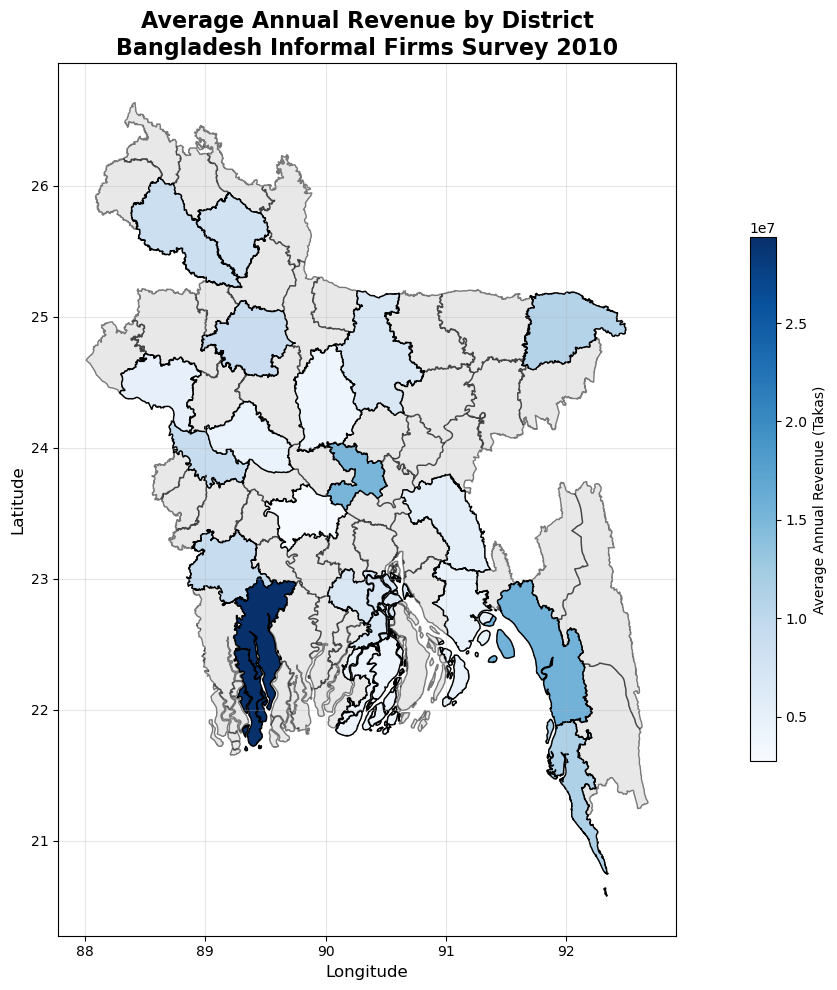


Average Revenue by District (Top 5):
           dist  avg_revenue  firm_count
9        KHULNA   29348763.0          87
2    CHITTAGONG   15540284.0         183
5         DHAKA   15112470.0         431
4   COX'S BAZAR   11285790.0          84
17       SYLHET   10867739.0          69


In [10]:
# Create geographic plot of average revenue
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot base map (all districts)
districtmap.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)

# Plot districts with data
plot_data_with_revenue = plot_data.dropna(subset=['avg_revenue'])
plot_data_with_revenue.plot(
    column='avg_revenue', 
    ax=ax, 
    legend=True,
    cmap='Blues',
    edgecolor='black',
    legend_kwds={'label': 'Average Annual Revenue (Takas)', 
                'orientation': 'vertical', 'shrink': 0.6}
)

ax.set_title('Average Annual Revenue by District\nBangladesh Informal Firms Survey 2010', 
            fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show summary statistics
print("\nAverage Revenue by District (Top 5):")
print(aggdata.nlargest(5, 'avg_revenue')[['dist', 'avg_revenue', 'firm_count']].round(0))

The figure above shows Average Revenue, denominated in local currency (Takas), in the year 2009 for businesses in the surveyed districts. A few things are made apparent on this plot. First of all, the survey was conducted only in a selection of districts, not the whole country, and only the surveyed districts are filled with some kind of color.

Are there any clear geographic patterns to annual revenue? Such a conclusion is difficult to draw based on the information on this map. The district with the lowest average revenue per firm (shaded in darkest blue) appears to be right in the center of the country. There are a number of other districts that have comparable average revenue. The district with the highest average revenue is shaded in light blue in the southwest of the country; no other district seems to have a comparably high average revenue per firm.

Now, let's take a closer look at the data for annual revenue.

## Analysis of Annual Revenue Variable

Let's explore the Annual Revenue variable through a series of histograms.

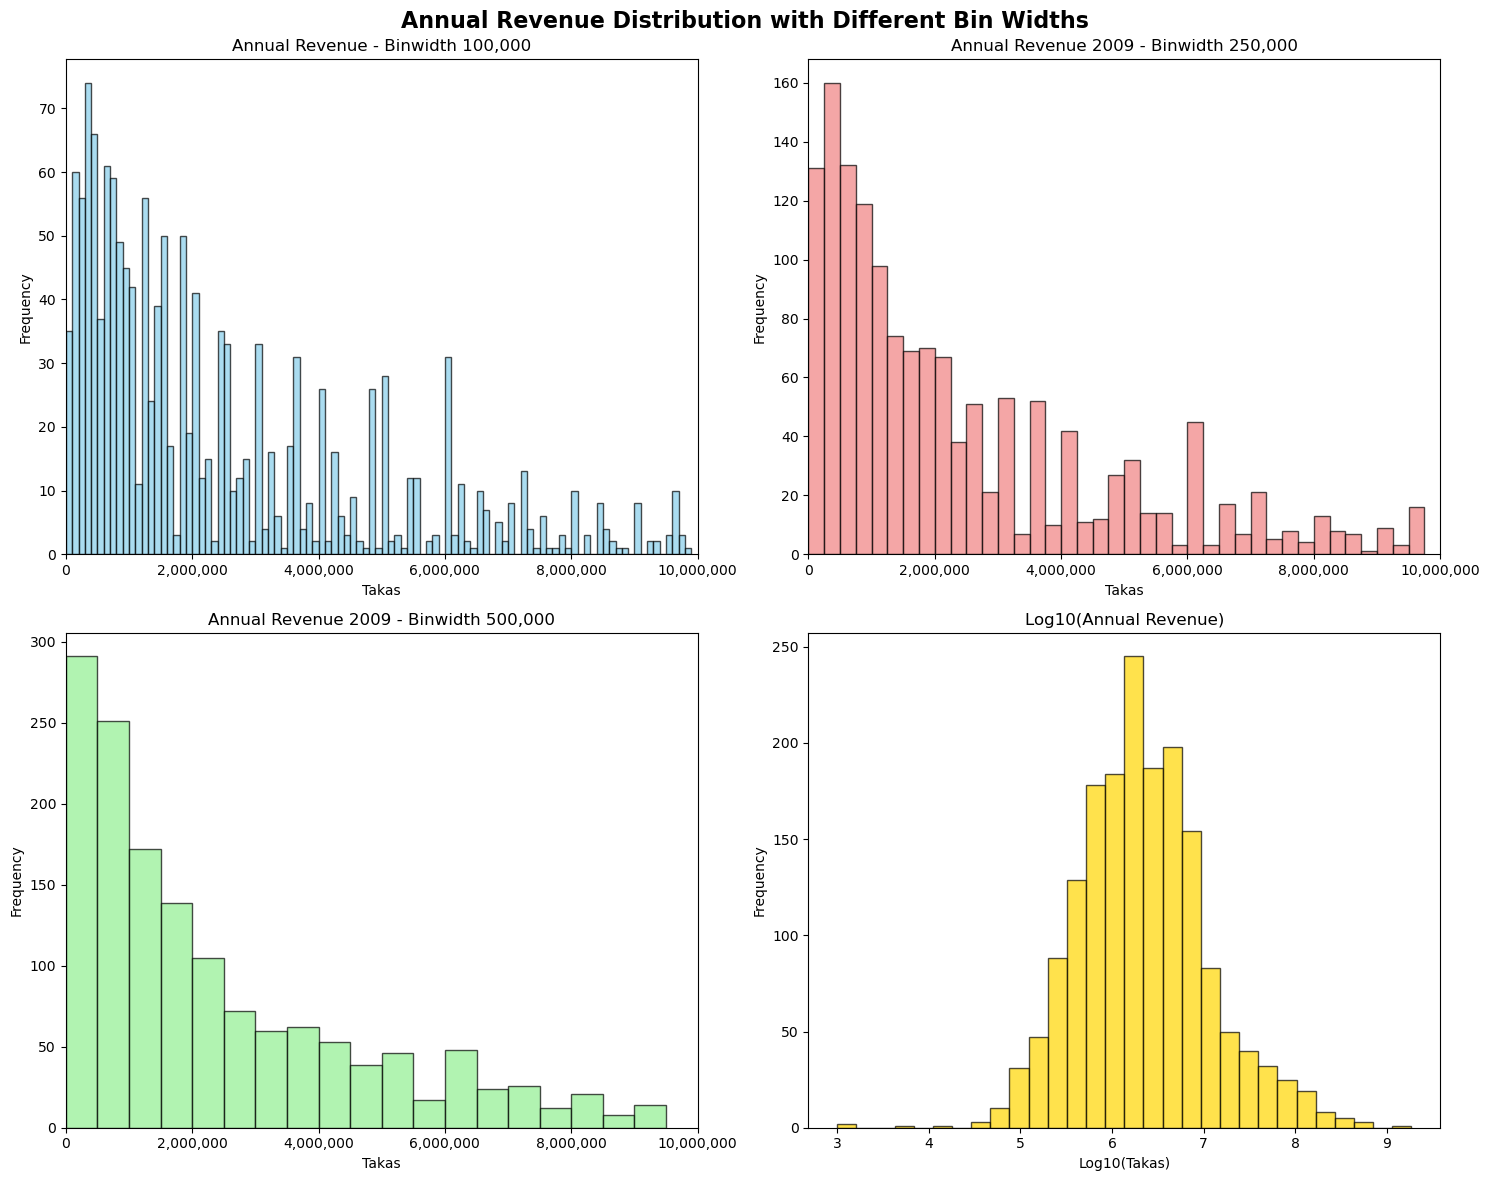

Revenue statistics:
Mean: 11,130,553
Median: 2,000,000
Std: 56,437,836
Min: 999
Max: 1,860,000,000


In [12]:
# Create histograms with different bin widths
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Annual Revenue Distribution with Different Bin Widths', fontsize=16, fontweight='bold')

# Remove rows with missing revenue data
revenue_data = surveydata['q4_7'].dropna()

# Histogram 1: binwidth equivalent to 100000
axes[0,0].hist(revenue_data, bins=np.arange(0, 10000000, 100000), 
               color='skyblue', alpha=0.7, edgecolor='black')
axes[0,0].set_xlim(0, 10000000)
axes[0,0].set_title('Annual Revenue - Binwidth 100,000')
axes[0,0].set_xlabel('Takas')
axes[0,0].set_ylabel('Frequency')
axes[0,0].xaxis.set_major_formatter(formatter)

# Histogram 2: binwidth equivalent to 250000
axes[0,1].hist(revenue_data, bins=np.arange(0, 10000000, 250000), 
               color='lightcoral', alpha=0.7, edgecolor='black')
axes[0,1].set_xlim(0, 10000000)
axes[0,1].set_title('Annual Revenue 2009 - Binwidth 250,000')
axes[0,1].set_xlabel('Takas')
axes[0,1].set_ylabel('Frequency')
axes[0,1].xaxis.set_major_formatter(formatter)

# Histogram 3: binwidth equivalent to 500000
axes[1,0].hist(revenue_data, bins=np.arange(0, 10000000, 500000), 
               color='lightgreen', alpha=0.7, edgecolor='black')
axes[1,0].set_xlim(0, 10000000)
axes[1,0].set_title('Annual Revenue 2009 - Binwidth 500,000')
axes[1,0].set_xlabel('Takas')
axes[1,0].set_ylabel('Frequency')
axes[1,0].xaxis.set_major_formatter(formatter)

# Histogram 4: Log transformation
log_revenue = np.log10(revenue_data.replace(0, np.nan).dropna())
axes[1,1].hist(log_revenue, bins=30, color='gold', alpha=0.7, edgecolor='black')
axes[1,1].set_title('Log10(Annual Revenue)')
axes[1,1].set_xlabel('Log10(Takas)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Revenue statistics:")
print(f"Mean: {revenue_data.mean():,.0f}")
print(f"Median: {revenue_data.median():,.0f}")
print(f"Std: {revenue_data.std():,.0f}")
print(f"Min: {revenue_data.min():,.0f}")
print(f"Max: {revenue_data.max():,.0f}")

Above histograms display distribution of values of annual revenue for 2009. I chose to use three histograms to display the same variable, with different binwidths, which allows us to view the data from an increasingly generalized perspective. We can see that the distribution is not normal--it is a negative exponential distribution (skewed to the left). The distribution makes sense, if one expects that most firms in Bangladesh are small and would not have a high revenue.

What do the differences in binwidth tell us? The histogram with binwidth of 100,000 demonstrates that the data periodically spikes, and does not appear as smooth as the next 2 histograms. These spikes likely result because survey respondents would tend to give estimated answers, corresponding to rounded increments.

The second histogram reduces the number of spikes substantially, and the third almost eliminates them entirely, creating a smooth staircase shape. I believe that the second histogram sufficiently manages the spikes without totally eliminating the variety of responses, so I believe that one is the best to use.

The logarithmic adjustment of the annual revenue variable creates a new histogram that displays the data as a normal distribution.

Let's take another view of business size, by comparing annual revenue to number of employees.

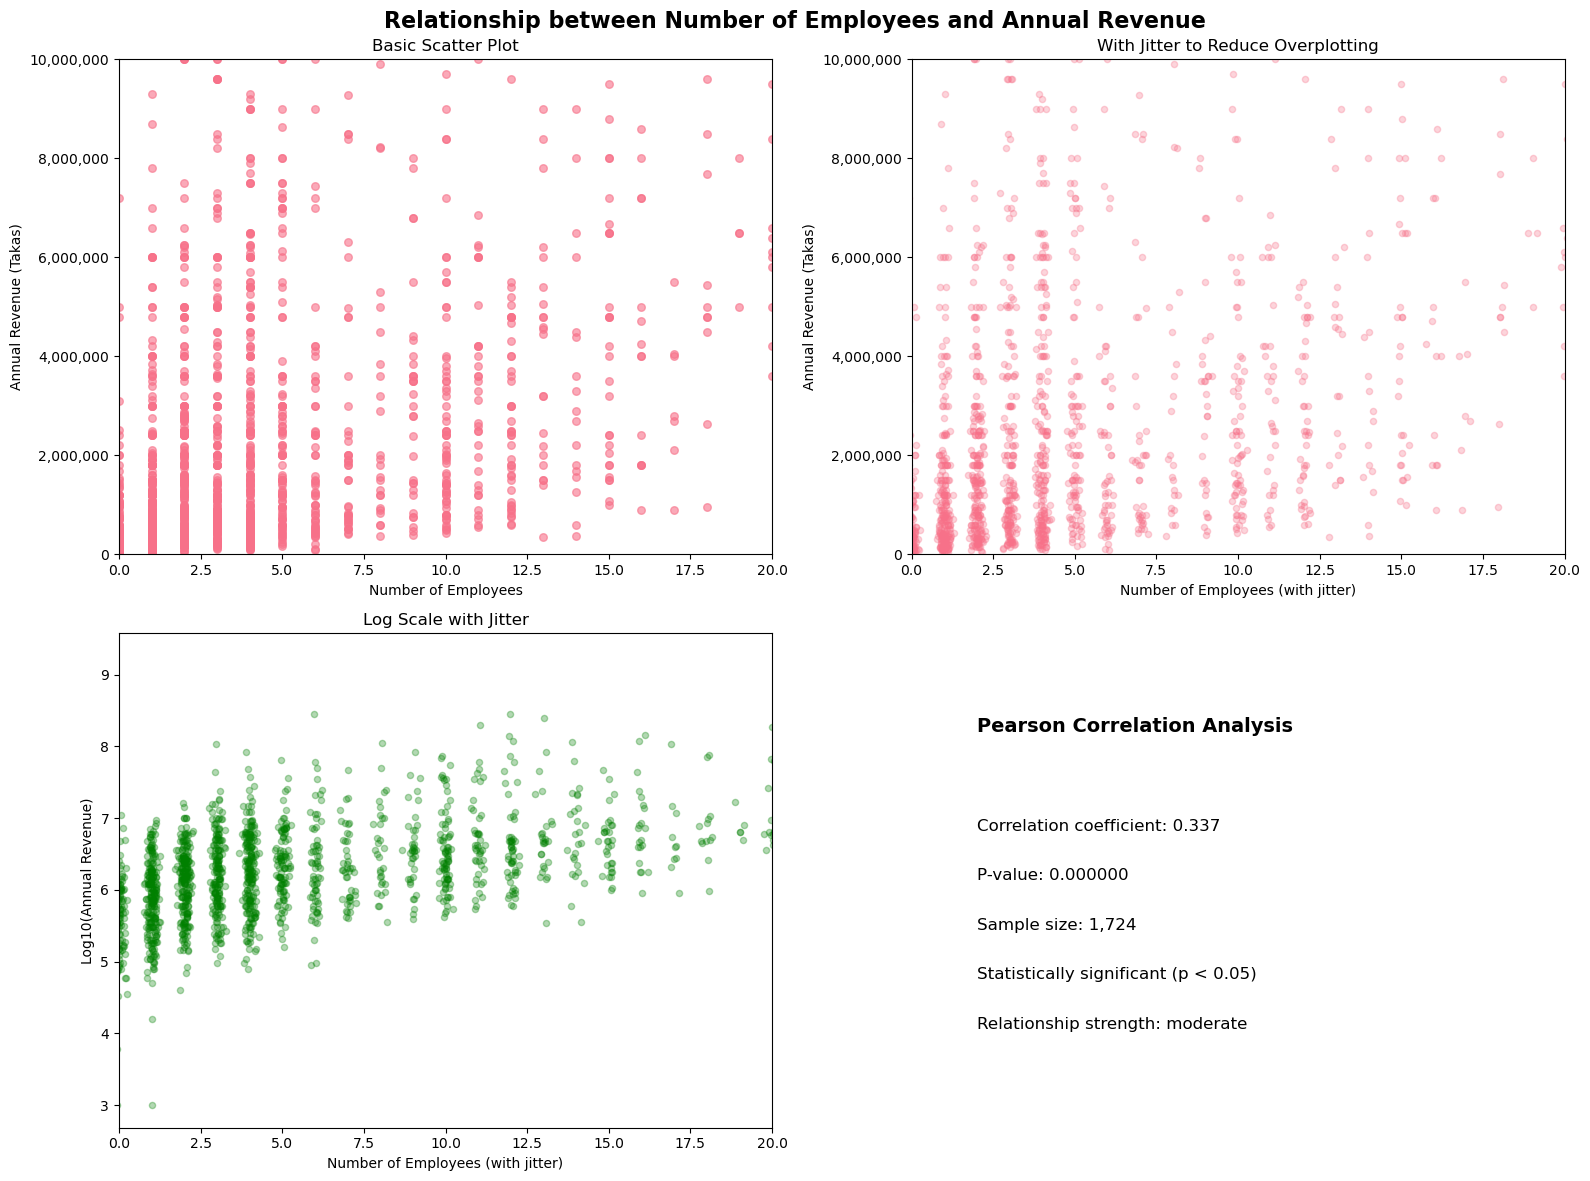

In [14]:
# Employee vs Revenue scatter plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Relationship between Number of Employees and Annual Revenue', fontsize=16, fontweight='bold')

# Remove rows with missing data for both variables
clean_data = surveydata.dropna(subset=['q4_7', 'q1_12a5a'])

# Plot 1: Basic scatter plot
axes[0,0].scatter(clean_data['q1_12a5a'], clean_data['q4_7'], alpha=0.6, s=30)
axes[0,0].set_xlim(0, 20)
axes[0,0].set_ylim(0, 10000000)
axes[0,0].set_xlabel('Number of Employees')
axes[0,0].set_ylabel('Annual Revenue (Takas)')
axes[0,0].set_title('Basic Scatter Plot')
axes[0,0].yaxis.set_major_formatter(formatter)

# Plot 2: With jitter (add small random noise to x-axis)
x_jitter = clean_data['q1_12a5a'] + np.random.normal(0, 0.1, len(clean_data))
axes[0,1].scatter(x_jitter, clean_data['q4_7'], alpha=0.3, s=20)
axes[0,1].set_xlim(0, 20)
axes[0,1].set_ylim(0, 10000000)
axes[0,1].set_xlabel('Number of Employees (with jitter)')
axes[0,1].set_ylabel('Annual Revenue (Takas)')
axes[0,1].set_title('With Jitter to Reduce Overplotting')
axes[0,1].yaxis.set_major_formatter(formatter)

# Plot 3: Log scale with jitter
log_revenue_clean = np.log10(clean_data['q4_7'].replace(0, np.nan).dropna())
emp_clean = clean_data.loc[clean_data['q4_7'] > 0, 'q1_12a5a']
x_jitter_log = emp_clean + np.random.normal(0, 0.1, len(emp_clean))

axes[1,0].scatter(x_jitter_log, log_revenue_clean, alpha=0.3, s=20, color='green')
axes[1,0].set_xlim(0, 20)
axes[1,0].set_xlabel('Number of Employees (with jitter)')
axes[1,0].set_ylabel('Log10(Annual Revenue)')
axes[1,0].set_title('Log Scale with Jitter')

# Plot 4: Correlation analysis
axes[1,1].axis('off')
correlation_coeff, p_value = stats.pearsonr(clean_data['q4_7'], clean_data['q1_12a5a'])
axes[1,1].text(0.1, 0.8, f'Pearson Correlation Analysis', fontsize=14, fontweight='bold')
axes[1,1].text(0.1, 0.6, f'Correlation coefficient: {correlation_coeff:.3f}', fontsize=12)
axes[1,1].text(0.1, 0.5, f'P-value: {p_value:.6f}', fontsize=12)
axes[1,1].text(0.1, 0.4, f'Sample size: {len(clean_data):,}', fontsize=12)

if p_value < 0.05:
    significance = "Statistically significant (p < 0.05)"
else:
    significance = "Not statistically significant (p >= 0.05)"
axes[1,1].text(0.1, 0.3, significance, fontsize=12)

# Interpretation
if abs(correlation_coeff) < 0.3:
    strength = "weak"
elif abs(correlation_coeff) < 0.7:
    strength = "moderate"
else:
    strength = "strong"
    
axes[1,1].text(0.1, 0.2, f'Relationship strength: {strength}', fontsize=12)

plt.tight_layout()
plt.show()

The plot above displays number of employees in the firm on the x axis, and annual revenue on the y axis. It is difficult to discern any clear pattern; We appear to have a problem with overplotting, as many of the data points appear to overlap. This probably results from the fact that number of employees is an integer, and is limited on the graph to a value of 20. The jitter helps somewhat to make clear the varied relationship between number of employees and annual revenue.

The application of logarithmic scaling seems to make clearer a positive relationship between annual revenue and number of employees.

The correlation value indicates that there is a relationship between the number of employees and annual revenue, albeit it cannot be characterized as a strong relationship.

## Analysis of Business Classifications

What type of businesses were surveyed, and is it possible to explore some of their characteristics? Perhaps a more insightful question would be, is it possible to determine if annual revenue varies by business sector?

The survey data includes information about the industry classification of the business; the business information is given via the ISIC code, an industry classification system. ISIC is a 4-tiered classification system, with the lower 3 tiers represented by a numeric code, and a corresponding top level represented by a letter. The lowest (and most granular) level is represented by a 4-digit code.

In [16]:
# Load and process ISIC classification data
isicdata = pd.read_csv('ISIC_Rev_3_english_structure.csv')

# Convert ISIC code to factor and create additional classification levels
surveydata['q1_2'] = surveydata['q1_2'].astype(str)
surveydata['ISIC2_code'] = surveydata['q1_2'].str[:2]

# Merge ISIC descriptions with survey data
# Create mapping dictionaries
isic_section_map = dict(zip(isicdata['Code'].astype(str), isicdata['SectionCode']))
isic_section_desc_map = dict(zip(isicdata['Code'].astype(str), isicdata['SectionDesc']))
isic2_desc_map = dict(zip(isicdata['Code'].astype(str), isicdata.get('Desc_short', isicdata['Description'])))
isic4_desc_map = dict(zip(isicdata['Code'].astype(str), isicdata['Description']))

# Apply mappings
surveydata['ISIC_section'] = surveydata['q1_2'].map(isic_section_map)
surveydata['ISIC_sectiondesc'] = surveydata['q1_2'].map(isic_section_desc_map)
surveydata['ISIC2_desc'] = surveydata['ISIC2_code'].map(isic2_desc_map)
surveydata['ISIC4_desc'] = surveydata['q1_2'].map(isic4_desc_map)

print("ISIC Classification Levels:")
print(f"Level 2 (ISIC2_desc): {surveydata['ISIC2_desc'].nunique()} unique categories")
print(f"Level 4 (ISIC4_desc): {surveydata['ISIC4_desc'].nunique()} unique categories")
print(f"Section level: {surveydata['ISIC_sectiondesc'].nunique()} unique categories")

ISIC Classification Levels:
Level 2 (ISIC2_desc): 3 unique categories
Level 4 (ISIC4_desc): 75 unique categories
Section level: 7 unique categories


In [17]:
# Display business counts by classification level
print("\n=== ISIC Level 2 Number of Businesses ===")
isic2_counts = surveydata['ISIC2_desc'].value_counts().head(10)
print(isic2_counts)

print("\n=== ISIC Level 4 Number of Businesses (Top 15) ===")
isic4_counts = surveydata['ISIC4_desc'].value_counts().head(15)
print(isic4_counts)

print("\n=== ISIC Section Level Number of Businesses ===")
section_counts = surveydata['ISIC_sectiondesc'].value_counts()
print(section_counts)


=== ISIC Level 2 Number of Businesses ===
ISIC2_desc
Communication        18
Land Transport        6
Transport Support     1
Name: count, dtype: int64

=== ISIC Level 4 Number of Businesses (Top 15) ===
ISIC4_desc
Retail sale of textiles, clothing, footwear and leather goods                                 217
Restaurants, bars and canteens                                                                179
Other retail sale in non-specialized stores                                                    99
Manufacture of structural metal products                                                       92
Other retail sale in specialized stores                                                        86
Retail sale of household appliances, articles and equipment                                    83
Manufacture of wearing apparel, except fur apparel                                             82
Retail sale of pharmaceutical and medical goods, cosmetic and toilet articles                  68
M

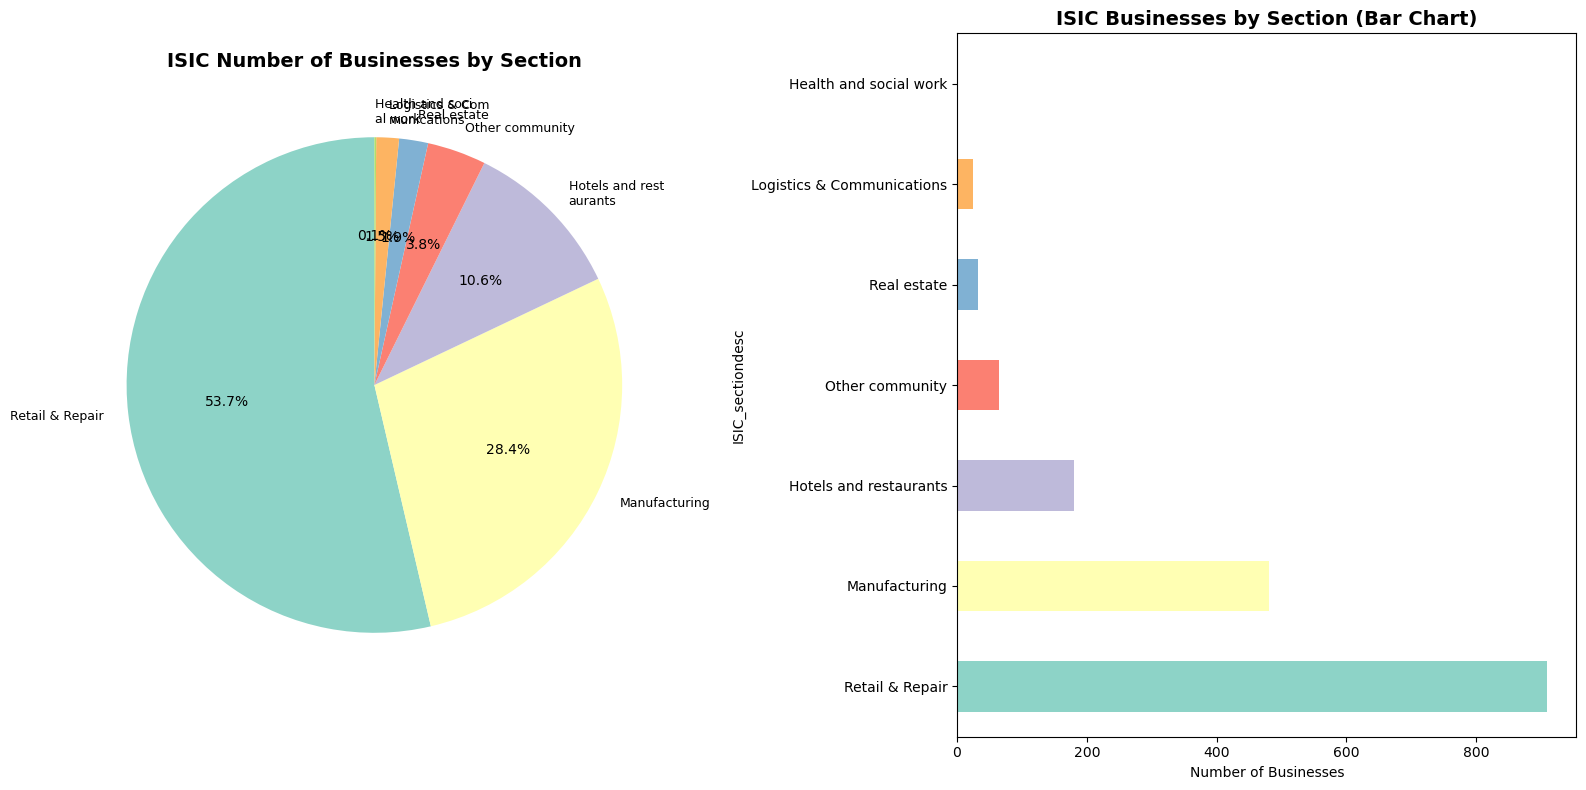


The most granular level of classification, Level 4, has 75 distinct values,
while Level 2 has 3 distinct values.
The ISIC Section level has 7 distinct values, which seems ideal for exploration.

As shown in the pie chart, over 50% of businesses are classified under 'Retail and Repair'.


In [18]:
# Create pie chart for ISIC sections
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Pie chart
section_counts_clean = surveydata['ISIC_sectiondesc'].dropna().value_counts()
colors = plt.cm.Set3(np.arange(len(section_counts_clean)))

wedges, texts, autotexts = ax1.pie(section_counts_clean.values, 
                                  labels=section_counts_clean.index, 
                                  autopct='%1.1f%%',
                                  colors=colors,
                                  startangle=90)
ax1.set_title('ISIC Number of Businesses by Section', fontsize=14, fontweight='bold')

# Wrap long labels
for text in texts:
    text.set_fontsize(9)
    wrapped_text = '\n'.join([text.get_text()[i:i+15] for i in range(0, len(text.get_text()), 15)])
    text.set_text(wrapped_text)

# Bar chart for better readability
section_counts_clean.plot(kind='barh', ax=ax2, color=colors)
ax2.set_title('ISIC Businesses by Section (Bar Chart)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Businesses')
ax2.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

print(f"\nThe most granular level of classification, Level 4, has {surveydata['ISIC4_desc'].nunique()} distinct values,")
print(f"while Level 2 has {surveydata['ISIC2_desc'].nunique()} distinct values.")
print(f"The ISIC Section level has {surveydata['ISIC_sectiondesc'].nunique()} distinct values, which seems ideal for exploration.")
print(f"\nAs shown in the pie chart, over 50% of businesses are classified under 'Retail and Repair'.")

The most granular level of classification, Level 4, has 76 distinct values in the data set, while Level 2 has 30 distinct values. For purposes of initial exploration (especially visually), both present a very large number of distinct values. However, the ISIC Section level has 7 distinct values, which seems to be an ideal number of values with which to explore. The other variables may be useful to conduct deeper analysis at some point. The risk of using the ISIC Section level will be that there is too much concentration in a few variables; indeed, looking at the pie chart shows that over 50% of businesses are classified under "Retail and Repair".

Let's begin by comparing profit levels for the different ISIC sections.

We will first facet annual revenue by ISIC section.

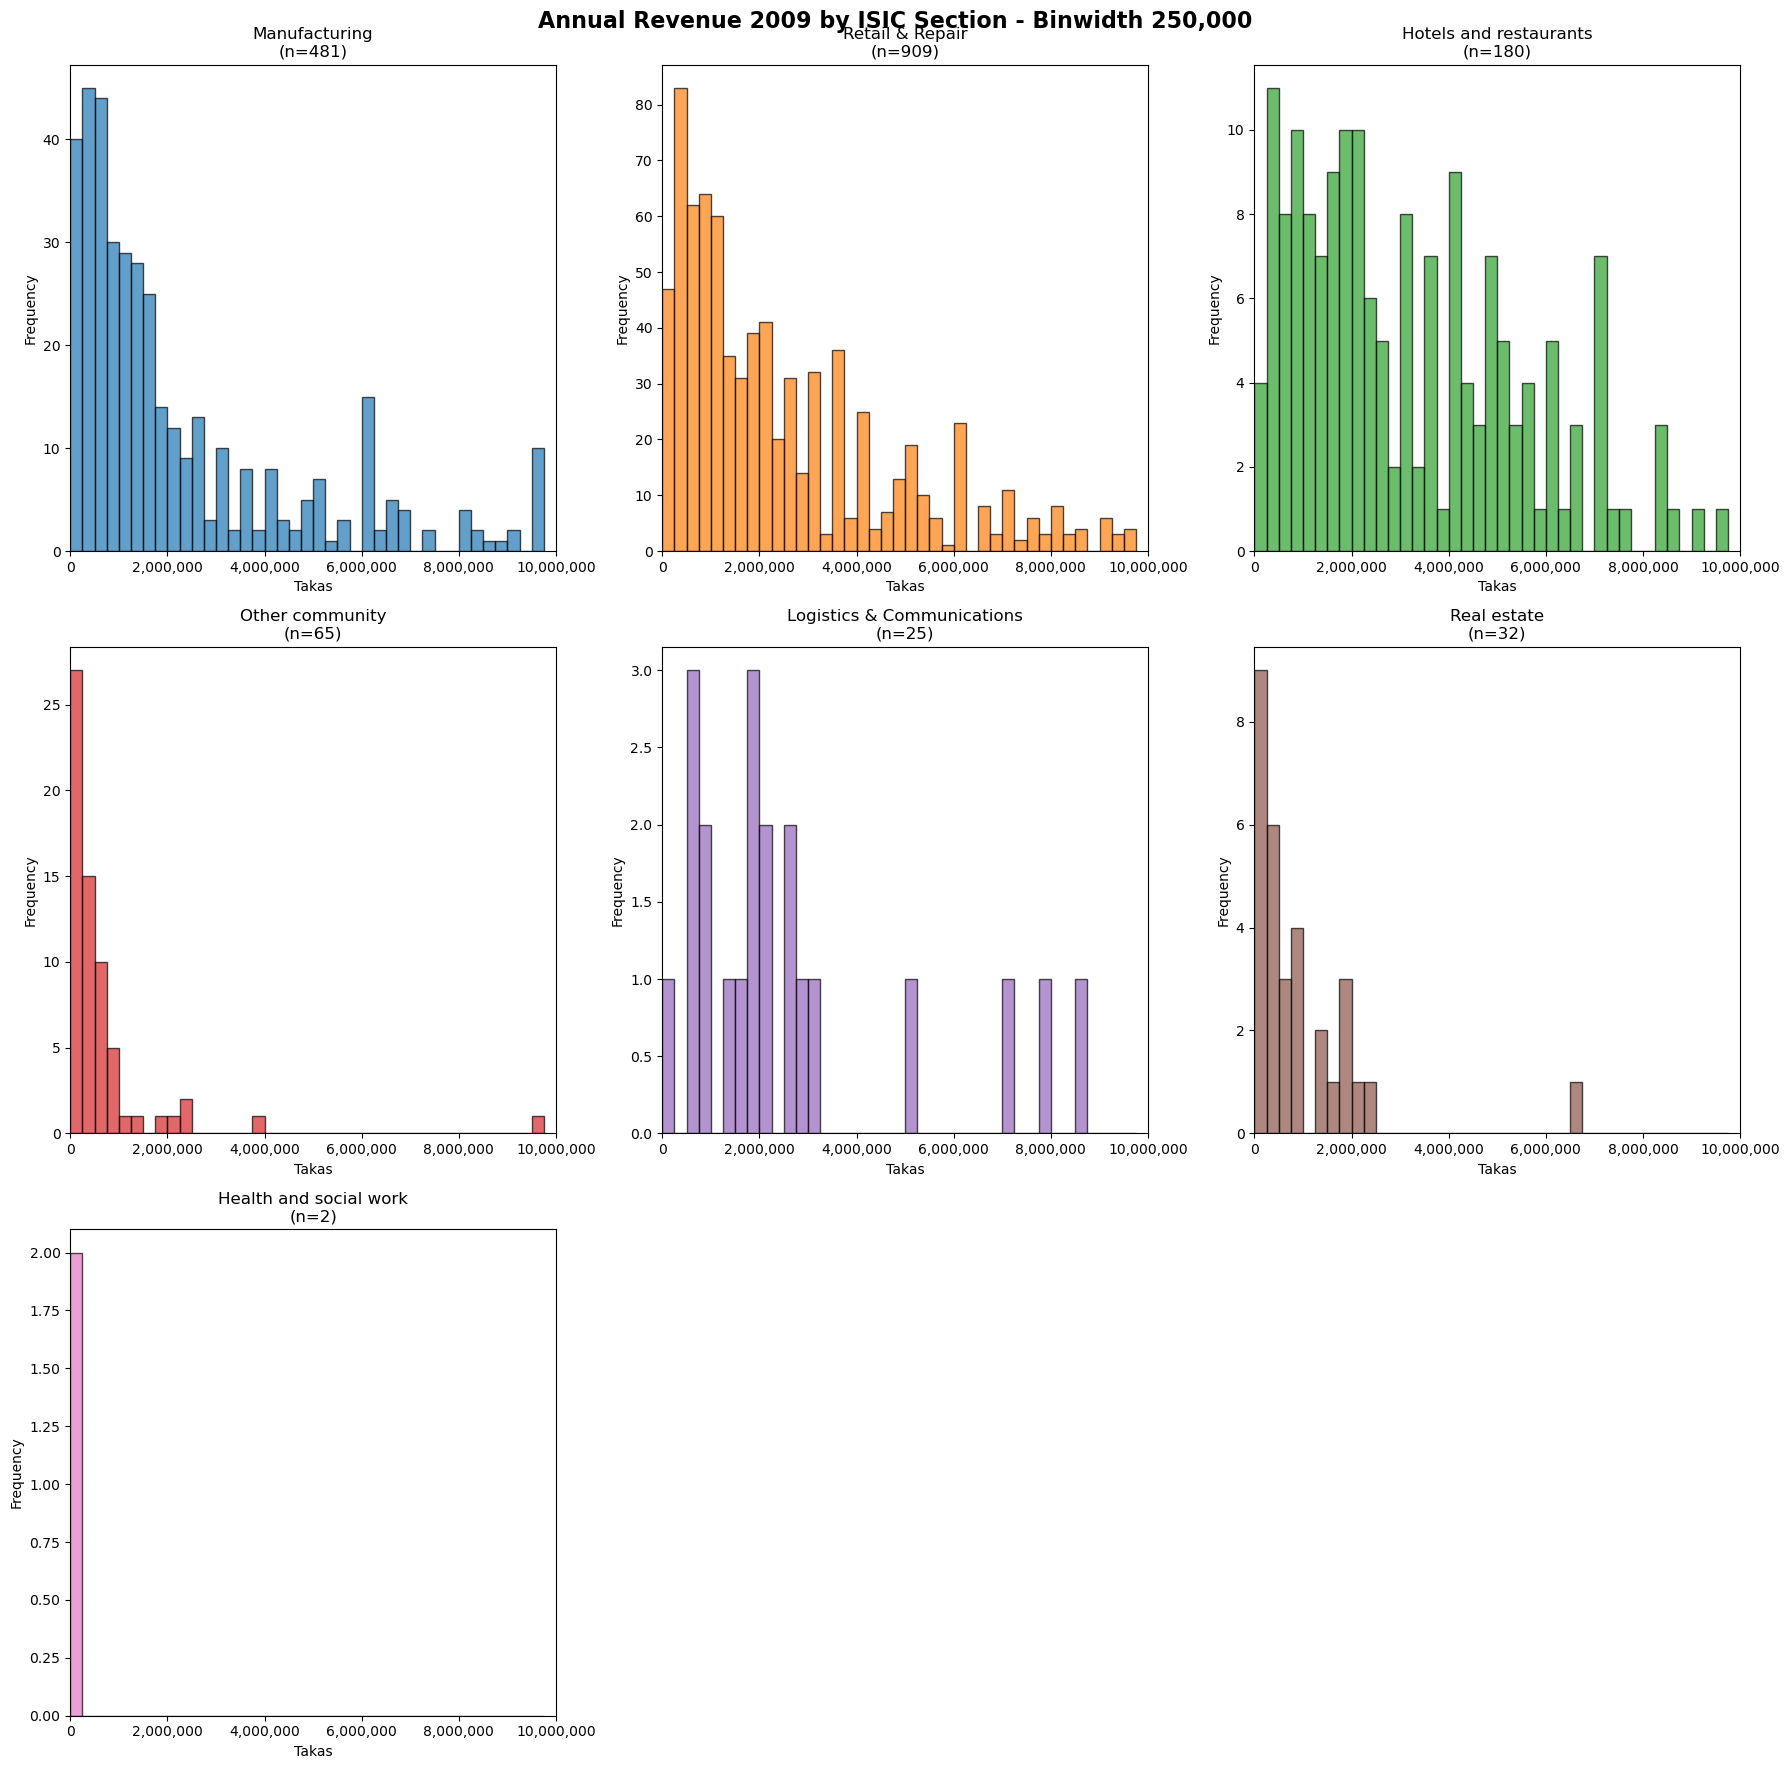

In [20]:
# Faceted histograms by ISIC section
sections_with_data = surveydata.dropna(subset=['ISIC_sectiondesc', 'q4_7'])
unique_sections = sections_with_data['ISIC_sectiondesc'].unique()
n_sections = len(unique_sections)

# Calculate grid dimensions
n_cols = 3
n_rows = (n_sections + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
fig.suptitle('Annual Revenue 2009 by ISIC Section - Binwidth 250,000', fontsize=16, fontweight='bold')

# Flatten axes array for easier indexing
axes = axes.flatten()

for i, section in enumerate(unique_sections):
    if pd.notna(section):
        section_data = sections_with_data[sections_with_data['ISIC_sectiondesc'] == section]['q4_7']
        
        axes[i].hist(section_data, bins=np.arange(0, 10000000, 250000), 
                    color=plt.cm.tab10(i), alpha=0.7, edgecolor='black')
        axes[i].set_xlim(0, 10000000)
        axes[i].set_title(f'{section}\n(n={len(section_data)})', fontsize=12)
        axes[i].set_xlabel('Takas')
        axes[i].set_ylabel('Frequency')
        axes[i].xaxis.set_major_formatter(formatter)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

On the surface, the faceted histograms reveal a variety of distributions. Sections Manufacturing, Retail & Repair, and "Other community" have a very clearly left-skewed exponential distribution. Hotels and restaurants, on the other hand, seem to have a very flat distribution.

Let's use box plots to examine the relationship between ISIC sections and revenue.

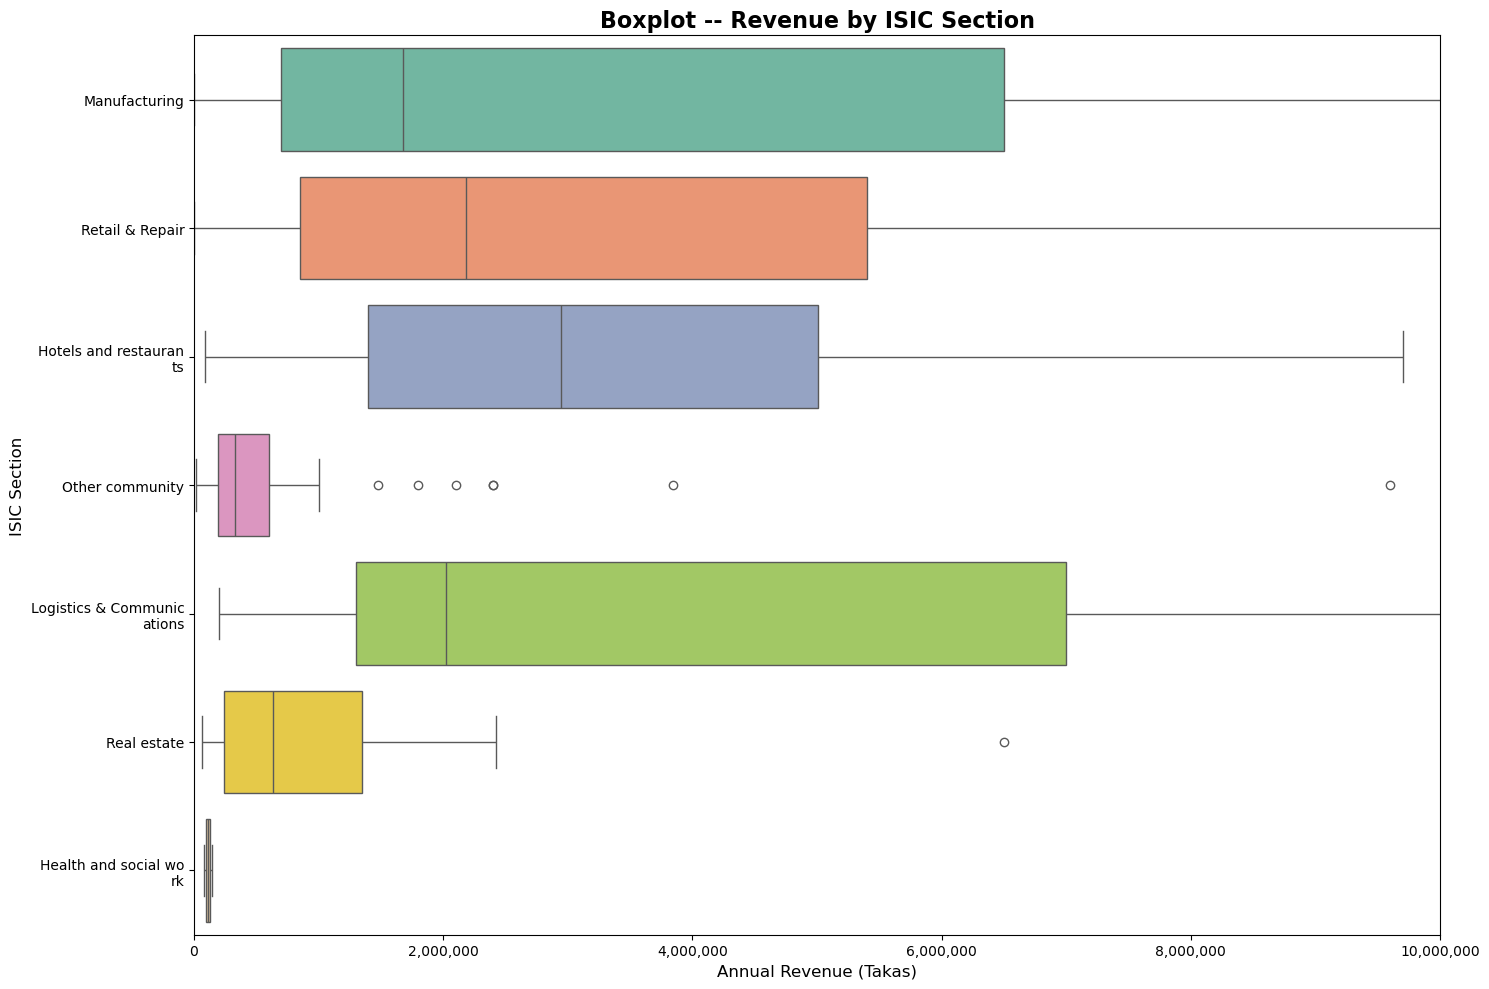


=== Revenue Statistics by ISIC Section ===
                            count        mean         std       min  \
ISIC_sectiondesc                                                      
Health and social work        2.0    112000.0     45255.0   80000.0   
Hotels and restaurants      180.0   4073332.0   4360816.0   90000.0   
Logistics & Communications   25.0   5711040.0   9310332.0  200000.0   
Manufacturing               481.0  19299894.0  97066514.0     999.0   
Other community              65.0    670338.0   1307207.0   16000.0   
Real estate                  32.0   1282688.0   2235339.0   60000.0   
Retail & Repair             909.0   9384055.0  31220530.0     999.0   

                                  25%        50%        75%           max  
ISIC_sectiondesc                                                           
Health and social work        96000.0   112000.0   128000.0  1.440000e+05  
Hotels and restaurants      1400000.0  2947500.0  5010000.0  2.800000e+07  
Logistics & 

In [22]:
# Box plot of revenue by ISIC section
plt.figure(figsize=(15, 10))

# Filter out missing section descriptions
plot_data = surveydata.dropna(subset=['ISIC_sectiondesc', 'q4_7'])

# Create box plot
box_plot = sns.boxplot(data=plot_data, y='ISIC_sectiondesc', x='q4_7', 
                      palette='Set2', orient='h')

# Set limits and formatting
plt.xlim(0, 10000000)
plt.xlabel('Annual Revenue (Takas)', fontsize=12)
plt.ylabel('ISIC Section', fontsize=12)
plt.title('Boxplot -- Revenue by ISIC Section', fontsize=16, fontweight='bold')

# Format x-axis labels
plt.gca().xaxis.set_major_formatter(formatter)

# Wrap y-axis labels
labels = [label.get_text() for label in plt.gca().get_yticklabels()]
wrapped_labels = ['\n'.join([label[i:i+20] for i in range(0, len(label), 20)]) for label in labels]
plt.gca().set_yticklabels(wrapped_labels, fontsize=10)

plt.tight_layout()
plt.show()

# Calculate summary statistics by section
print("\n=== Revenue Statistics by ISIC Section ===")
summary_stats = plot_data.groupby('ISIC_sectiondesc')['q4_7'].describe()
print(summary_stats.round(0))

The box plot does reveal variation of revenue levels across Sections; Hotels & Restaurants show the highest median level of profit, and Health & Social Work shows the lowest level of median profit (note though the relatively small number of observations in the data set for this category, as evidenced by the pie chart). Manufacturing, Logistics & Communications, and Retail & Repair have comparable median levels. Logistics & Communications has the widest difference between the 1st and 3rd quartiles.

Let's have a closer look at certain ISIC sections, first by generating summary statistics, then by reconciling these statistics against histograms for those sections.